In [5]:
import pandas as pd

Xf = pd.read_pickle("data/processed/Xf.pkl")
meta = pd.read_pickle("data/processed/meta.pkl")


In [6]:
# Prepare train / test data

from sklearn.model_selection import train_test_split

y = meta["label"]
X_model = Xf.loc[y.index]

X_train, X_test, y_train, y_test = train_test_split(
    X_model, y, test_size=0.2, random_state=42, stratify=y
)

X_train.shape, X_test.shape


((160, 8000), (40, 8000))

In [7]:
# Train XGBoost model

from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    eval_metric="logloss",
    random_state=42
)

model.fit(X_train, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.9, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

In [8]:
# Evaluate performance

from sklearn.metrics import roc_auc_score

proba = model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, proba)
auc


np.float64(0.694235588972431)

/Users/dohoonkim/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


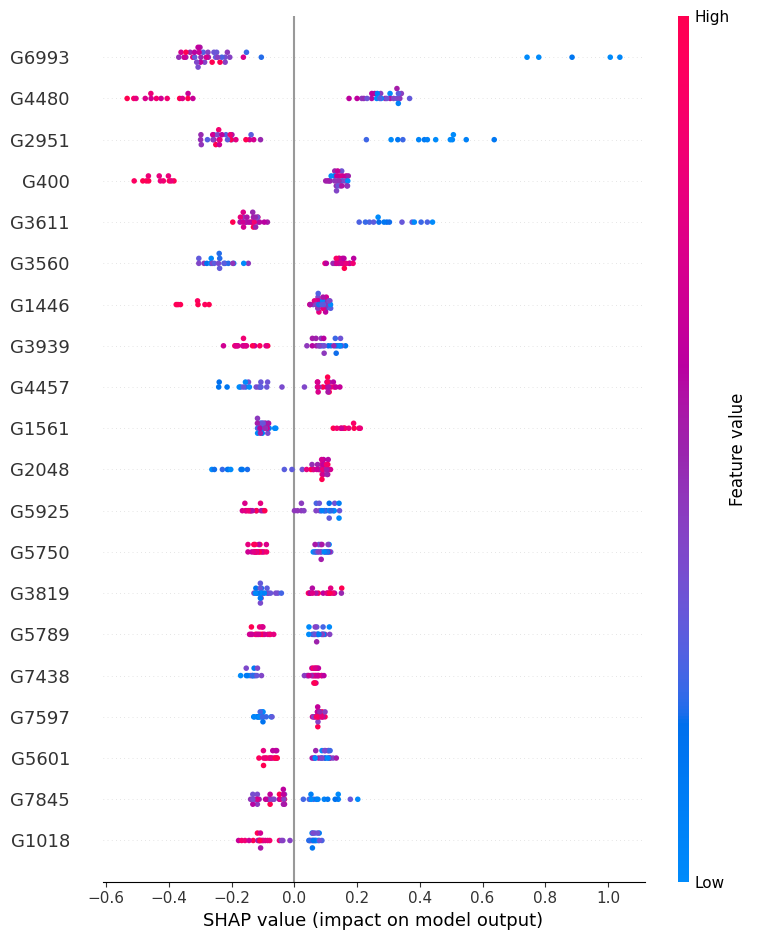

In [9]:
# Explain model with SHAP

import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, show=False)


In [10]:
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_val_score
from xgboost import XGBClassifier

y = meta["label"]
X_model = Xf.loc[y.index]

model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    eval_metric="logloss",
    random_state=42
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(model, X_model, y, cv=cv, scoring="roc_auc")

scores, scores.mean(), scores.std()


(array([0.6540404 , 0.55137845, 0.56140351, 0.5839599 , 0.61403509]),
 np.float64(0.5929634692792588),
 np.float64(0.03736526351185393))

In [11]:
model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    eval_metric="logloss",
    random_state=42
)

model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.9, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

In [12]:
import numpy as np
from sklearn.metrics import (
    confusion_matrix, classification_report,
    average_precision_score, precision_recall_curve
)

proba = model.predict_proba(X_test)[:, 1]
pred = (proba >= 0.5).astype(int)

cm = confusion_matrix(y_test, pred)
cm


array([[12,  7],
       [ 9, 12]])

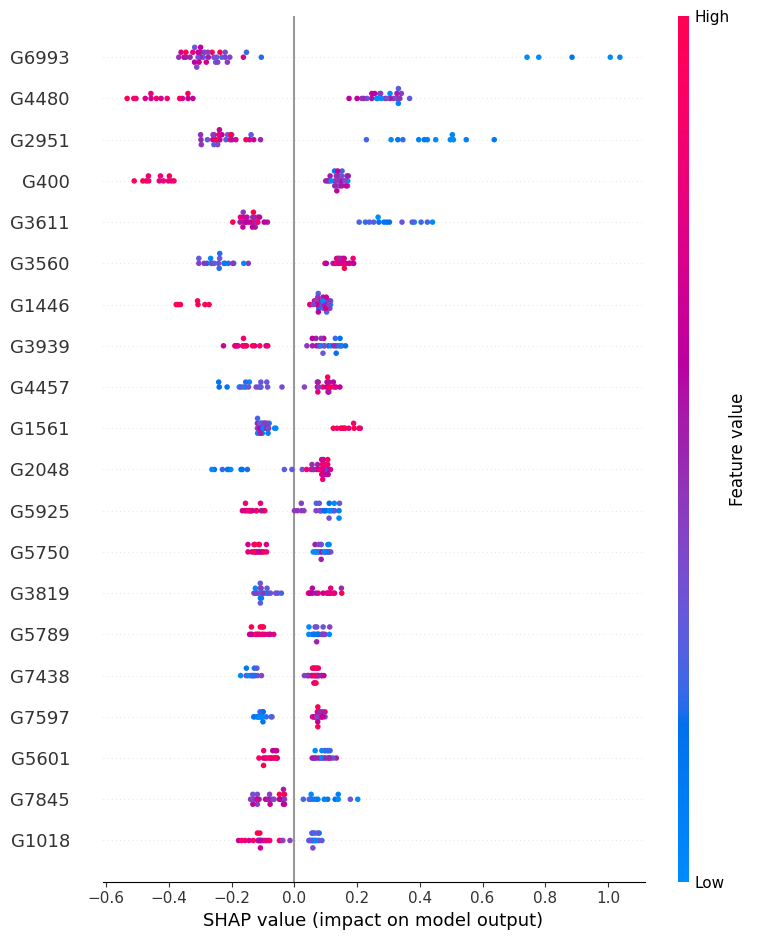

In [13]:
# Explain model with SHAP

import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, show=False)


In [14]:
import os
os.makedirs("data/models", exist_ok=True)

model.save_model("data/models/xgb_model.json")


In [15]:
import os
import numpy as np
import pandas as pd

os.makedirs("data/processed", exist_ok=True)

# shap_values가 (n_samples, n_features) 형태라고 가정
# (binary인데 shap_values가 list로 나오는 버전이면 아래 (C) 참고)
mean_abs_shap = np.abs(shap_values).mean(axis=0)

imp = pd.DataFrame({
    "gene": X_test.columns,
    "mean_abs_shap": mean_abs_shap
}).sort_values("mean_abs_shap", ascending=False)

imp.to_csv("data/processed/shap_importance.csv", index=False)
imp.head(20)


,gene,mean_abs_shap
6993,G6993,0.351298
4480,G4480,0.331959
2951,G2951,0.289228
400,G400,0.230345
3611,G3611,0.204908
3560,G3560,0.191389
1446,G1446,0.129757
3939,G3939,0.123591
4457,G4457,0.118877
1561,G1561,0.117967
